In [1]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

from tqdm import tqdm
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

2025-11-30 17:43:36.464982: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-30 17:43:36.465993: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-30 17:43:36.471399: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-30 17:43:36.486228: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-30 17:43:36.507761: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been 

In [2]:
def load_real_samples(scale=False):
    # We load 20,000 samples only to avoid memory issues, you can  change this value
    X = np.load("fractal_images.npy")
    # Scale samples in range [-127, 127]
    if scale:
        X = (X - 0.5) * 2
    return X 

def grid_plot(images, epoch=None, name='', n=3, save=False, scale=False):
    import os

    if scale:
        images = (images + 1) / 2.0

    for idx in range(n * n):
        plt.subplot(n, n, 1 + idx)
        plt.axis('off')
        plt.imshow(images[idx])

    fig = plt.gcf()
    fig.suptitle(f"{name}  {epoch if epoch is not None else ''}", fontsize=14)

    if save:
        os.makedirs("results", exist_ok=True)
        if isinstance(epoch, int):
            filename = f"results/{name}_e{epoch:03d}.png"
        else:
            filename = f"results/{name}.png"
        plt.savefig(filename, bbox_inches='tight')
        plt.close()
    else:
        plt.show()


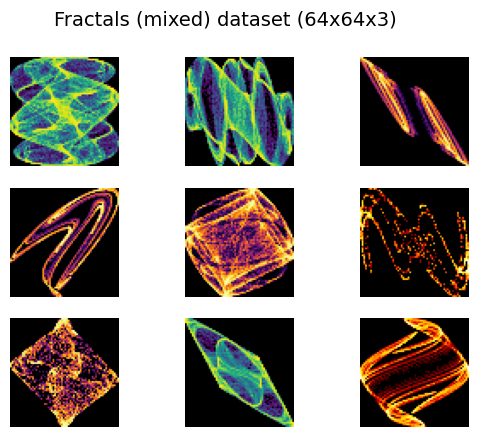

In [3]:
dataset = load_real_samples()
grid_plot(dataset[np.random.randint(0, 1000, 9)], name='Fractals (mixed) dataset (64x64x3)', n=3)

In [4]:
labels=np.load("fractal_labels.npy")

zero = dataset[labels == 0]
one = dataset[labels == 1]
two = dataset[labels == 2]
three = dataset[labels == 3]


In [5]:
subsets = [zero, one, two, three]
subset_names = ['dream', 'hopalong', 'de_jong', 'clifford']

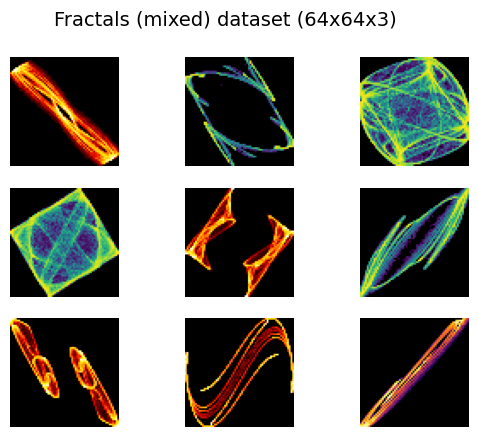

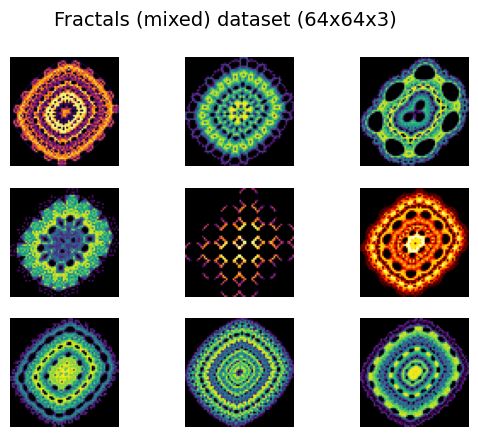

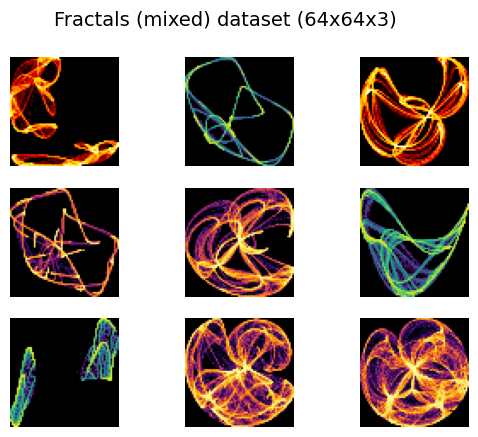

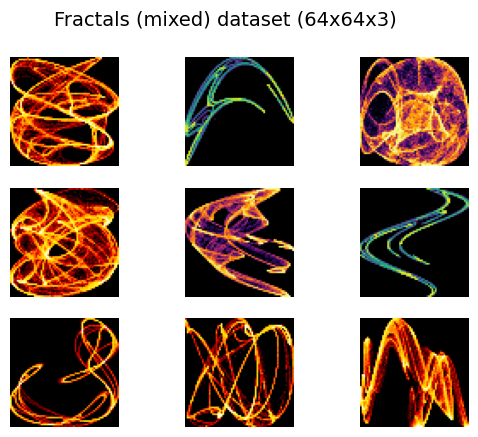

In [6]:
for set in subsets:
    grid_plot(set[np.random.randint(0, 1000, 9)], name='Fractals (mixed) dataset (64x64x3)', n=3)

In [8]:
from tensorflow.keras.layers import Dense, Flatten, Conv2D, Conv2DTranspose, Reshape

def build_conv_net(in_shape, out_shape, n_downsampling_layers=4, filters=256, out_activation='sigmoid'):
    """
    Build a basic convolutional network
    """
    default_args=dict(kernel_size=(3,3), strides=(2,2), padding='same', activation='relu')

    input = tf.keras.Input(shape=in_shape)
    x = Conv2D(filters=filters, name='enc_input', **default_args)(input)

    for _ in range(n_downsampling_layers):
        x = Conv2D(**default_args, filters=filters)(x)

    x = Flatten()(x)
    x = Dense(out_shape, activation=out_activation, name='enc_output')(x)

    model = tf.keras.Model(inputs=input, outputs=x, name='Encoder')

    model.summary()
    return model


def build_deconv_net(latent_dim, n_upsampling_layers=4, filters=256, activation_out='sigmoid'):
    """
    Build a deconvolutional network for decoding/upscaling latent vectors

    When building the deconvolutional architecture, usually it is best to use the same layer sizes that
    were used in the downsampling network and the Conv2DTranspose layers are used instead of Conv2D layers.
    Using identical layers and hyperparameters ensures that the dimensionality of our output matches the
    shape of our input images.
    """
    input = tf.keras.Input(shape=(latent_dim,))
    x = Dense(4 * 4 * 64, input_dim=latent_dim, name='dec_input')(input)
    x = Reshape((4, 4, 64))(x) # This matches the output size of the downsampling architecture

    default_args=dict(kernel_size=(3,3), strides=(2,2), padding='same', activation='relu')

    for i in range(n_upsampling_layers):
        x = Conv2DTranspose(filters=filters, **default_args)(x)

    # This last convolutional layer converts back to 3 channel RGB image
    x = Conv2D(filters=3, kernel_size=(3,3), padding='same', activation=activation_out, name='dec_output')(x)

    model = tf.keras.Model(inputs=input, outputs=x, name='Decoder')
    model.summary()
    return model


--- Training CAE for dream, shape (6000, 64, 64, 3) ---


I0000 00:00:1764521485.891251 2042977 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-11-30 17:51:25.927940: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2343] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "Encoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 64, 64, 3)]       0         
                                                                 
 enc_input (Conv2D)          (None, 32, 32, 64)        1792      
                                                                 
 conv2d (Conv2D)             (None, 16, 16, 64)        36928     
                                                                 
 conv2d_1 (Conv2D)           (None, 8, 8, 64)          36928     
                                                                 
 conv2d_2 (Conv2D)           (None, 4, 4, 64)          36928     
                                                                 
 conv2d_3 (Conv2D)           (None, 2, 2, 64)          36928     
                                                                 
 flatten (Flatten)           (None, 256)               0   

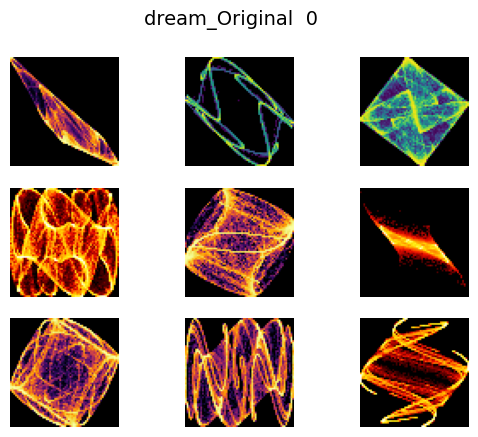

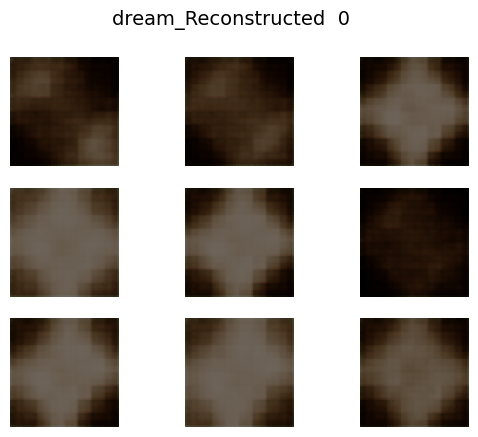


Epoch: 1
1/1 [==============================] - 0s 40ms/step


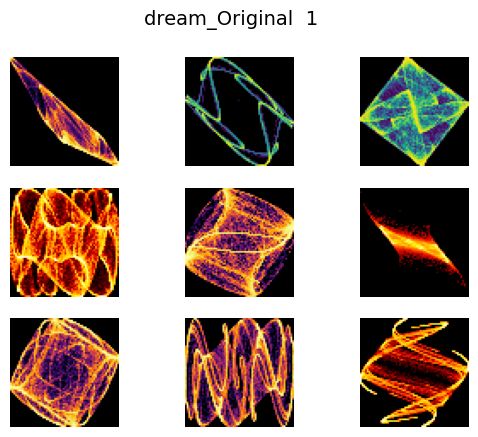

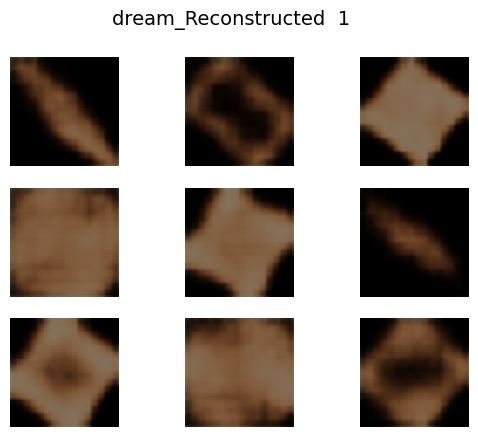


Epoch: 2
1/1 [==============================] - 0s 44ms/step


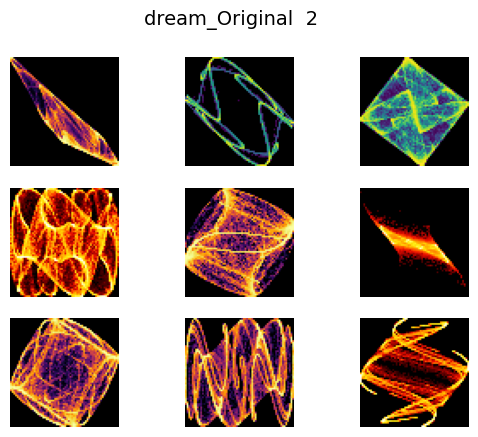

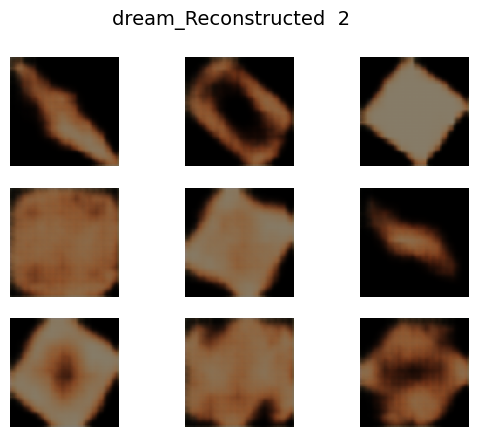


Epoch: 3
1/1 [==============================] - 0s 46ms/step


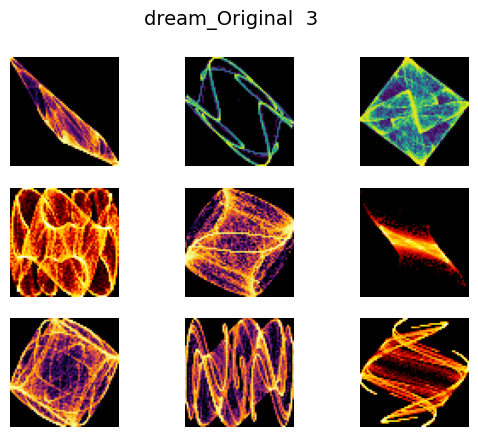

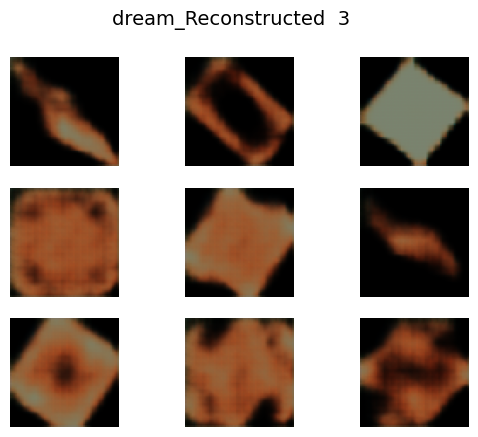


Epoch: 4
1/1 [==============================] - 0s 37ms/step


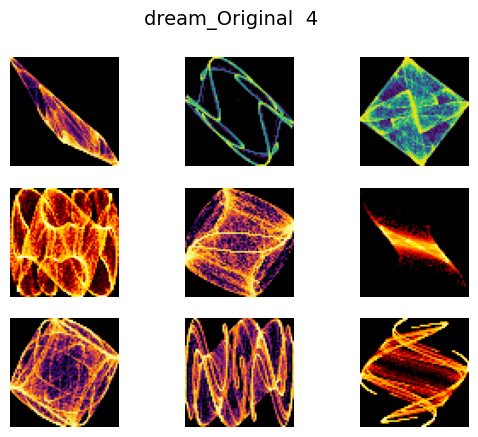

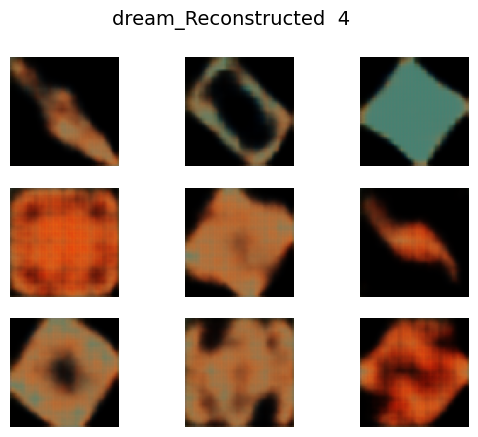


Epoch: 5
1/1 [==============================] - 0s 38ms/step


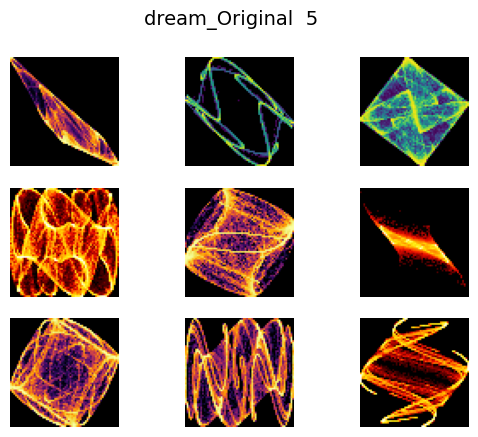

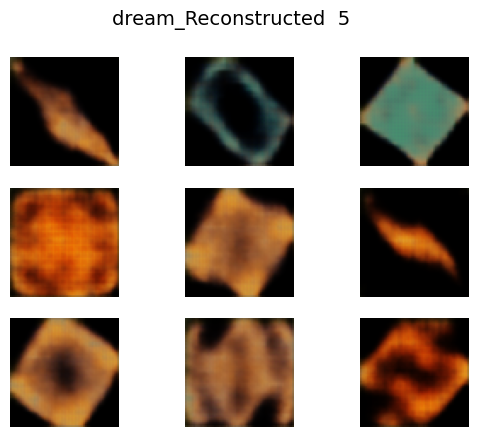


Epoch: 6
1/1 [==============================] - 0s 43ms/step


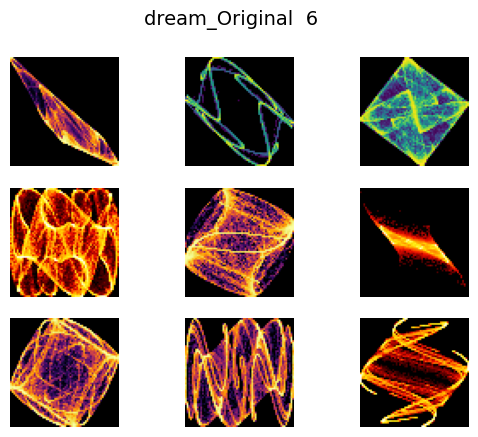

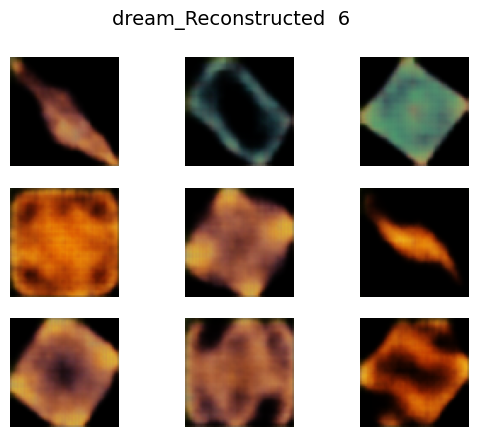


Epoch: 7
1/1 [==============================] - 0s 36ms/step


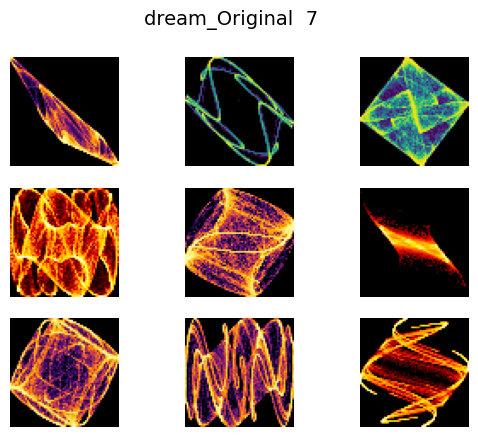

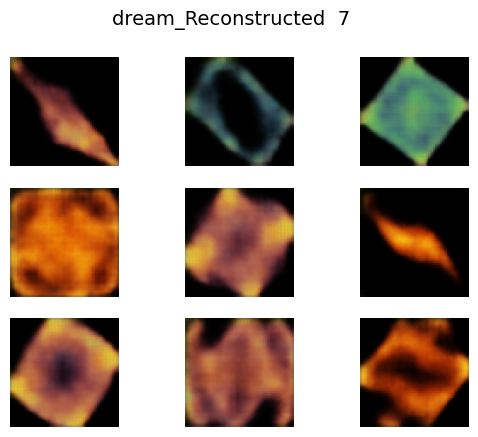


Epoch: 8
1/1 [==============================] - 0s 38ms/step


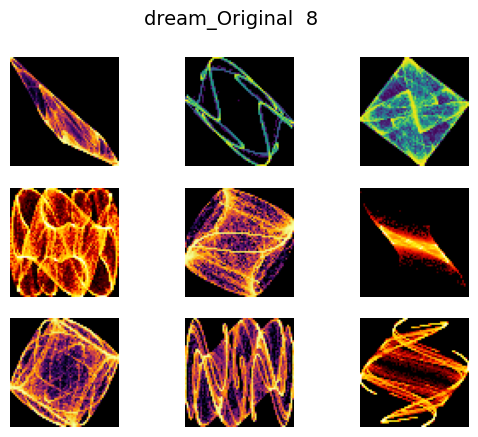

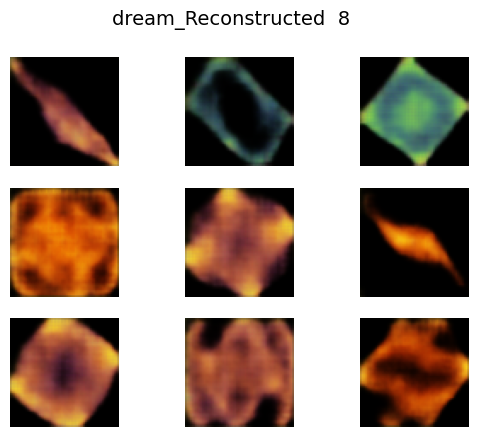


Epoch: 9
1/1 [==============================] - 0s 38ms/step


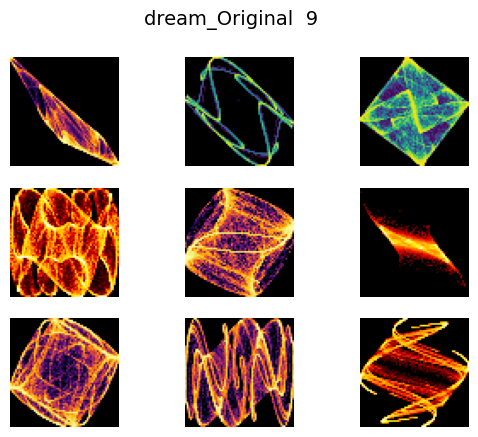

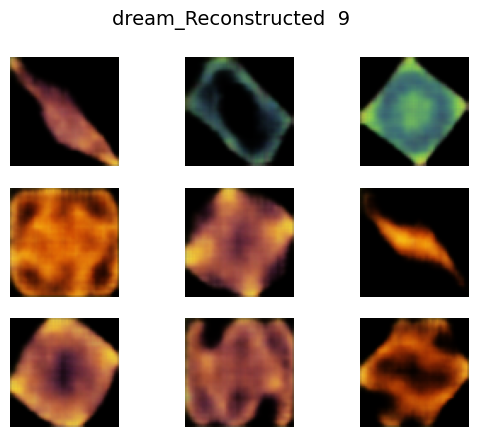


Epoch: 10
1/1 [==============================] - 0s 59ms/step


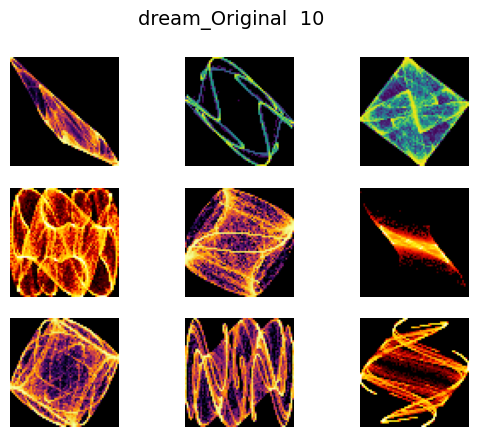

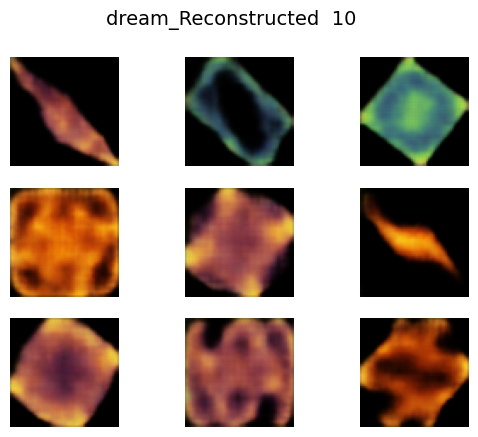


Epoch: 11
1/1 [==============================] - 0s 20ms/step


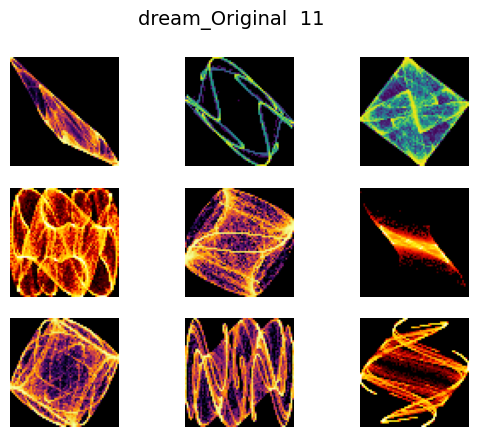

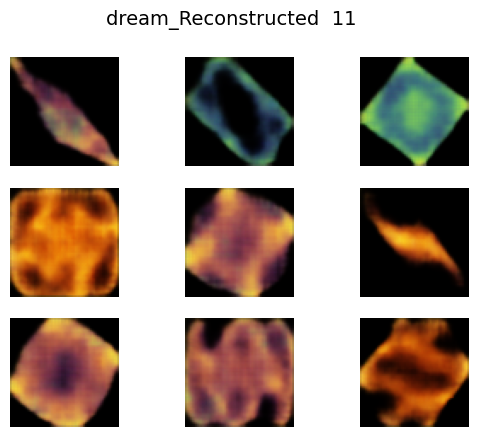


Epoch: 12
1/1 [==============================] - 0s 30ms/step


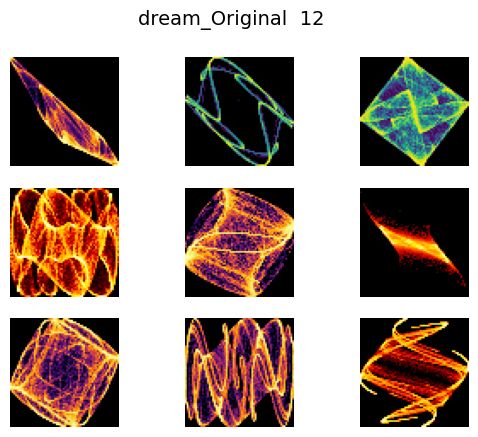

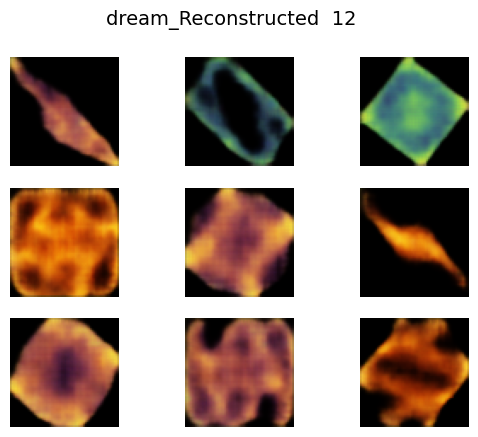


Epoch: 13
1/1 [==============================] - 0s 49ms/step


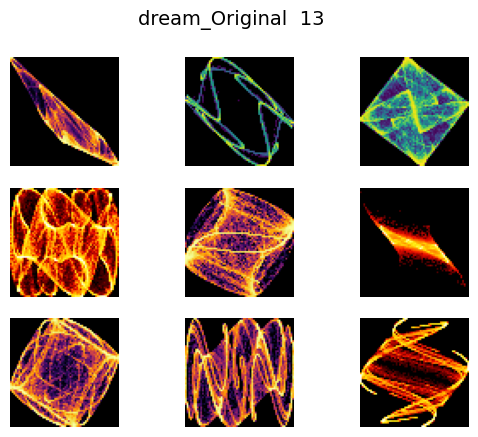

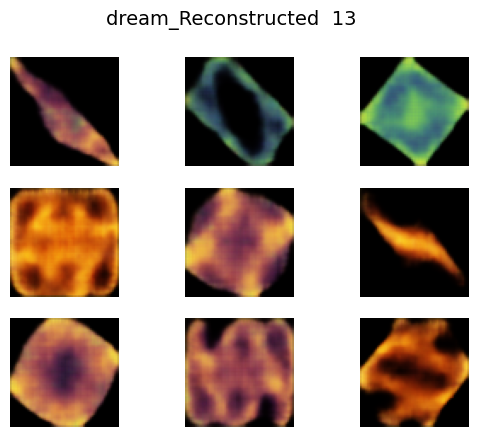


Epoch: 14
1/1 [==============================] - 0s 54ms/step


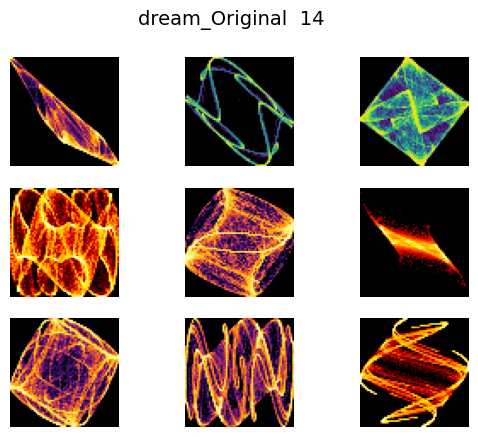

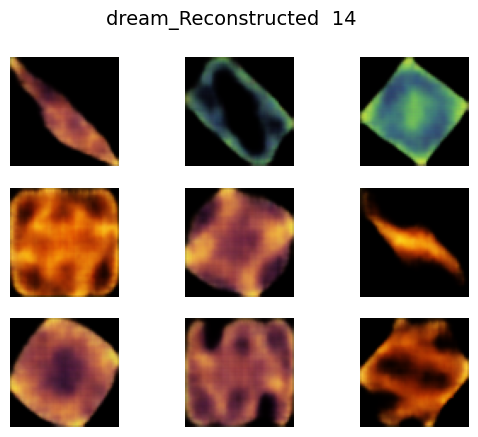


Epoch: 15
1/1 [==============================] - 0s 46ms/step


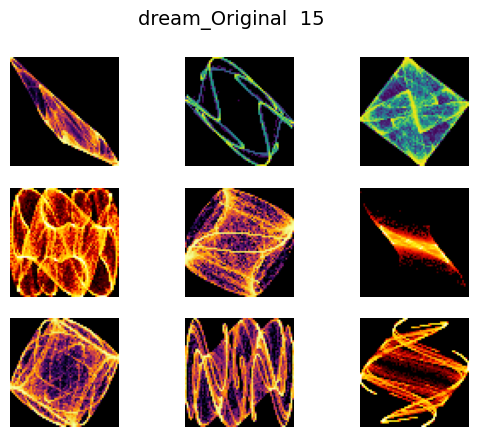

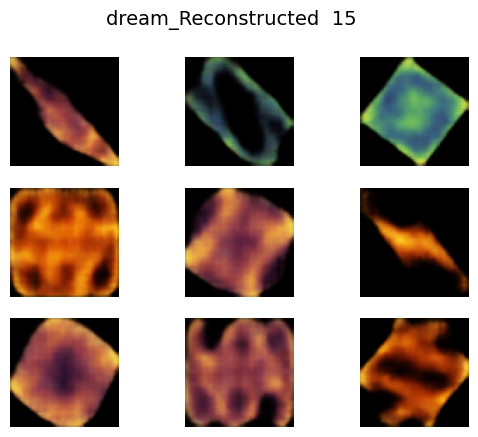


Epoch: 16
1/1 [==============================] - 0s 27ms/step


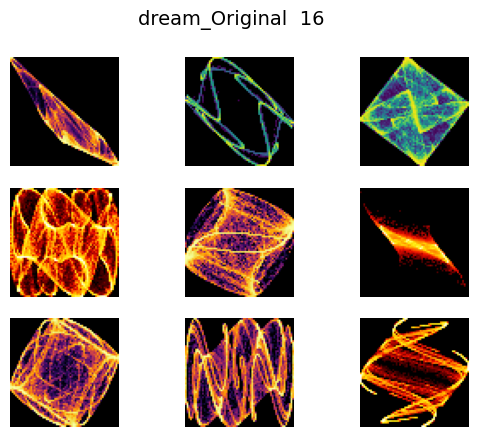

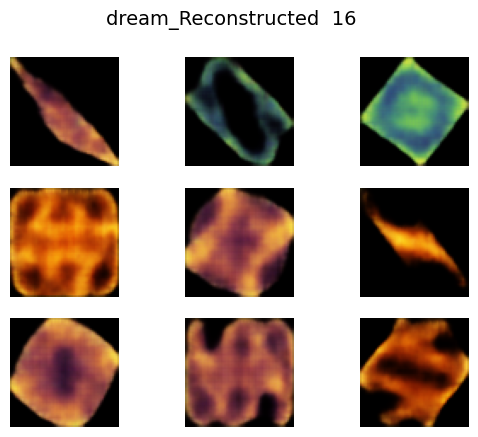


Epoch: 17
1/1 [==============================] - 0s 31ms/step


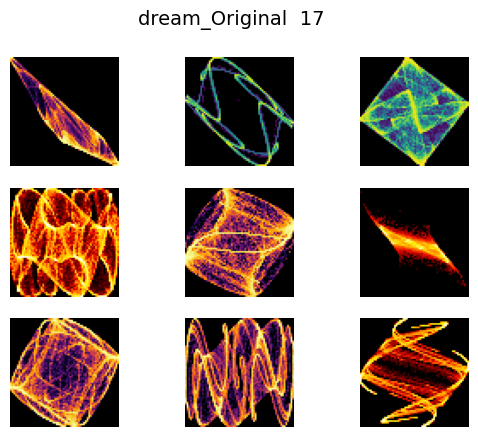

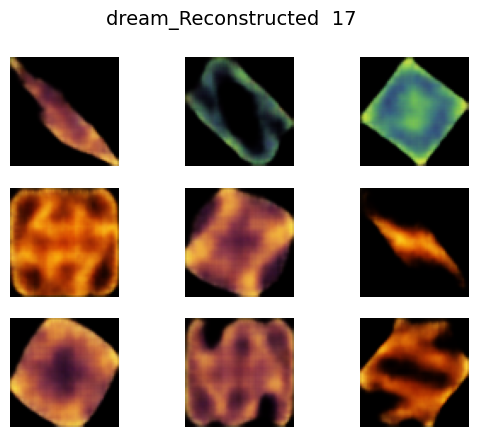


Epoch: 18
1/1 [==============================] - 0s 42ms/step


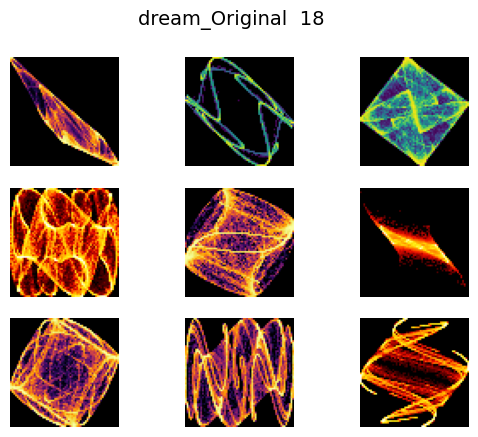

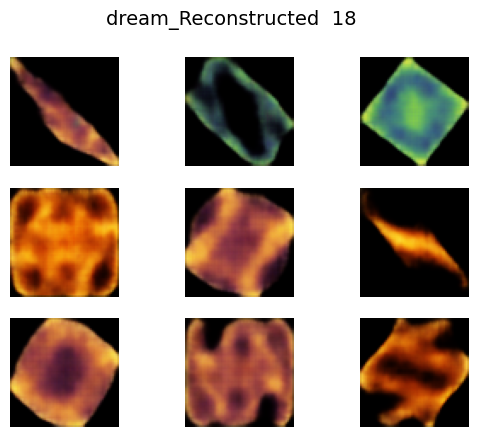


Epoch: 19
1/1 [==============================] - 0s 35ms/step


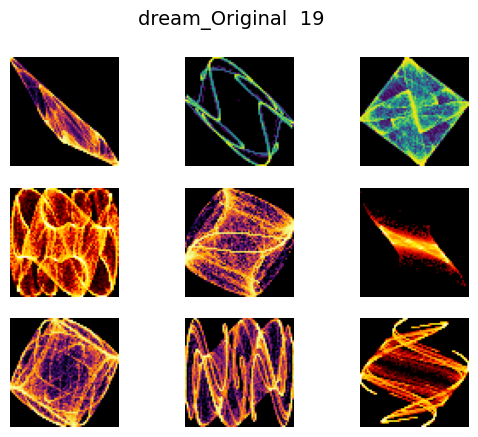

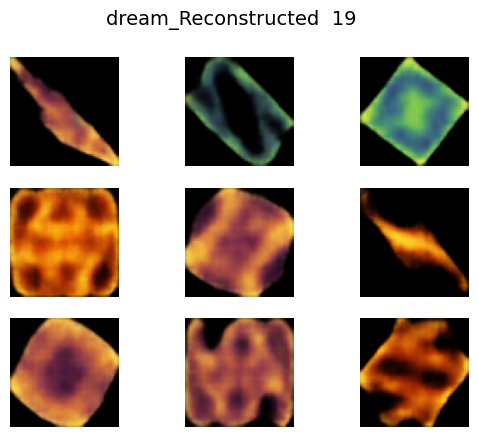


Epoch: 20
40/94 [===========>..................] - ETA: 6s - loss: 0.2810

KeyboardInterrupt: 

In [9]:
from tensorflow import keras

train_cae = True
latent_dim = 256
num_filters = 128
epochs=30


cae_models = {}   # <-- qui salvi tutti i tuoi modelli CAE

def build_convolutional_autoencoder(data_shape, latent_dim, filters=128):
    encoder = build_conv_net(in_shape=data_shape, out_shape=latent_dim, filters=filters)
    decoder = build_deconv_net(latent_dim, activation_out='sigmoid', filters=filters)

    autoencoder = tf.keras.Sequential([encoder, decoder])
    autoencoder.compile(loss='binary_crossentropy', optimizer='adam')
    return autoencoder

for data, name in zip(subsets, subset_names):
    data = np.array(data)
    print(f"\n--- Training CAE for {name}, shape {data.shape} ---")

    cae = build_convolutional_autoencoder(data.shape[1:], latent_dim, num_filters)

    if train_cae:
        for epoch in range(epochs):
            print('\nEpoch:', epoch)
            cae.fit(x=data, y=data, epochs=1, batch_size=64)

            samples = data[:9]
            reconstructed = cae.predict(samples)
            grid_plot(samples, epoch, name=f'{name}_Original', n=3, save=False)
            grid_plot(reconstructed, epoch, name=f'{name}_Reconstructed', n=3, save=False)

        cae.save(f'cae_{name}.keras')
        print(f"Modello salvato come cae_{name}.keras")

    # Carico il modello specifico e lo salvo in un dizionario
    cae_loaded = keras.models.load_model(f'cae_{name}.keras')
    cae_models[name] = cae_loaded  # <-- salva il modello distinto

    # Visualizzazione finale
    samples = data[:9]
    reconstructed = cae_loaded.predict(samples)
    grid_plot(samples, 0, name=f'{name}_Original_loaded', n=3, save=True)
    grid_plot(reconstructed, 0, name=f'{name}_Reconstructed_loaded', n=3, save=True)


In [ ]:
from tensorflow import keras

train_vae = False  # Flag di controllo

class Sampling(tf.keras.layers.Layer):
    """
    Custom layer for the variational autoencoder
    It takes two vectors as input - one for means and other for variances of the latent variables described by a multimodal gaussian
    Its output is a latent vector randomly sampled from this distribution
    """
    def call(self, inputs):
        z_mean, z_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_var) * epsilon

def build_vae(data_shape, latent_dim, filters=128):

    # Building the encoder - starts with a simple downsampling convolutional network
    encoder = build_conv_net(data_shape, latent_dim*2, filters=filters)

    # Adding special sampling layer that uses the reparametrization trick
    z_mean = Dense(latent_dim)(encoder.output)
    z_var = Dense(latent_dim)(encoder.output)
    z = Sampling()([z_mean, z_var])

    # Connecting the two encoder parts
    encoder = tf.keras.Model(inputs=encoder.input, outputs=z)

    # Defining the decoder which is a regular upsampling deconvolutional network
    decoder = build_deconv_net(latent_dim, activation_out='sigmoid', filters=filters)
    vae = tf.keras.Model(inputs=encoder.input, outputs=decoder(z))

    # Define a custom layer for the KL loss calculation
    class KLLossLayer(tf.keras.layers.Layer):
        def call(self, inputs):
            z_mean, z_var = inputs
            kl_loss = -0.5 * tf.reduce_sum(z_var - tf.square(z_mean) - tf.exp(z_var) + 1)
            # Add the KL loss to the model's losses
            self.add_loss(kl_loss / tf.cast(tf.keras.backend.prod(data_shape), tf.float32))
            return inputs  # Pass through the inputs unchanged

    # Apply the custom layer to z_mean and z_var
    _, _ = KLLossLayer()([z_mean, z_var])

    vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='binary_crossentropy')

    return encoder, decoder, vae

In [ ]:
train_vae = True  # o False per saltare il training

latent_dim = 128
num_filters = 128
epochs = 50

for data, name in zip(subsets, subset_names):
    data = np.array(data)

    print(f"\n\n--- Training VAE for class {name} ---")

    encoder, decoder, vae = build_vae(data.shape[1:], latent_dim, filters=num_filters)

    if train_vae:
        for epoch in range(epochs):
            print('\nEpoch:', epoch)

            vae.fit(x=data, y=data, epochs=1, batch_size=8)

            # Generazione casuale da latent space
            coefficient = 6
            latent_vectors = np.random.randn(9, latent_dim)
            images = decoder(latent_vectors / coefficient)

            grid_plot(images, epoch, 
                      name=f'{name}_VAE_generated', n=3, save=False)

        # Salvataggio modelli singoli
        vae.save(f'vae_{name}.keras')
        encoder.save(f'encoder_{name}.keras')
        decoder.save(f'decoder_{name}.keras')
        print(f"💾 Salvati: vae_{name}.keras, encoder_{name}.keras, decoder_{name}.keras")

    # Caricamento modelli (sia che train_vae=True o False)
    vae = keras.models.load_model(f'vae_{name}.keras', custom_objects={'Sampling': Sampling})
    encoder = keras.models.load_model(f'encoder_{name}.keras', custom_objects={'Sampling': Sampling})
    decoder = keras.models.load_model(f'decoder_{name}.keras', custom_objects={'Sampling': Sampling})

    # Visualizzazione ricostruzione finale
    samples = data[:9]
    reconstructed = vae.predict(samples)
    grid_plot(samples, 0, name=f'{name}_Original_loaded', n=3, save=True)
    grid_plot(reconstructed, 0, name=f'{name}_Reconstructed_loaded', n=3, save=True)




In [ ]:
def get_batch(generator, dataset, batch_size=64):
    """
    Fetches one batch of data and ensures no memory leaks by using TensorFlow operations.
    """
    half_batch = batch_size // 2

    # Generate fake images
    latent_vectors = tf.random.normal(shape=(half_batch, latent_dim))
    fake_data = generator(latent_vectors, training=False)

    # Select real images
    idx = np.random.randint(0, dataset.shape[0], half_batch)
    real_data = dataset[idx]

    # Combine
    X = tf.concat([real_data, fake_data], axis=0)
    y = tf.concat([tf.ones((half_batch, 1)), tf.zeros((half_batch, 1))], axis=0)

    return X, y


def train_gan(generator, discriminator, gan, dataset, latent_dim, n_epochs=50, batch_size=64):
    """
    Train the GAN with memory-efficient updates and clear session management.
    """
    batches_per_epoch = dataset.shape[0] // batch_size

    for epoch in range(n_epochs):
        for batch in tqdm(range(batches_per_epoch)):
            # Train Discriminator
            X, y = get_batch(generator, dataset, batch_size)
            discriminator_loss = discriminator.train_on_batch(X, y)

            # Train Generator
            latent_vectors = tf.random.normal(shape=(batch_size, latent_dim))
            y_gan = tf.ones((batch_size, 1))
            generator_loss = gan.train_on_batch(latent_vectors, y_gan)

        # Generate and visualize after each epoch
        noise = tf.random.normal(shape=(16, latent_dim))
        generated_images = generator(noise, training=False)
        
        grid_plot(generated_images.numpy(), epoch, name='Generated Images', n=3, scale=True)

        # Clear backend session to free memory
        tf.keras.backend.clear_session()

In [ ]:
from tensorflow import keras

train_gan_flag = True   # Flag di controllo

latent_dim = 256
n_epochs = 50

gan_models = {}
generators = {}
discriminators = {}

for data, name in zip(subsets, subset_names):
    data = np.array(data)
    print(f"\n\n--- Training GAN for class {name} ---")

    discriminator, generator, gan = build_gan(data.shape[1:], latent_dim, filters=128)

    data_scaled = data / 255.0

    if train_gan_flag:
        train_gan(generator, discriminator, gan, data_scaled, latent_dim, n_epochs=n_epochs)

        generator.save(f'generator_{name}.keras')
        discriminator.save(f'discriminator_{name}.keras')
        gan.save(f'gan_{name}.keras')
        print(f"Salvati: generator_{name}.keras, discriminator_{name}.keras, gan_{name}.keras")

    generator = keras.models.load_model(f'generator_{name}.keras')
    generators[name] = generator

    noise = tf.random.normal(shape=(16, latent_dim))
    generated_images = generator(noise, training=False)
    grid_plot(generated_images.numpy(), 0, name=f'{name}_Generated_loaded', n=3, scale=True)
